# Generate ASKAP FRBs

I want to calculate P(U) for ASKAP. To do that, I need to generate the m_r distribution for ASKAP. Then I plan to place them in DECaLs and HSC galaxies to calculate P(U) for m_r < 24 and m_r < 26.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
params = {'axes.labelsize':20,
         'axes.titlesize':20,
         'xtick.labelsize':20,
         'ytick.labelsize':20}
pylab.rcParams.update(params)
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=False)
import matplotlib

In [2]:
# from frb.frb_surveys import mock
import pandas, time
import numpy as np
from chime_ffff_pz.path import priors
from path_simulations import run
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units
import scipy.stats as stats

In [3]:
import os
os.environ['CHIME_SANDBOX'] = '/arc/projects/chime_frb/bandersen/path-simulations/simulation_results/SIMULATIONS_FINAL/'

In [4]:
! pip install --user /arc/home/bandersen/FRB

Processing /arc/home/bandersen/FRB
  Preparing metadata (setup.py) ... done
  Created wheel for FRB: filename=FRB-0.1.dev0-py3-none-any.whl size=97552320 sha256=de70f661de30cb57c45fa8bf9f70f72ac475c55a70d0834bef8dace1908f1357
  Stored in directory: /tmp/pip-ephem-wheel-cache-19dmu87r/wheels/95/4e/13/1718150238560f5bd07e63ae52fc00a61dcebb03de28bd34ba
Successfully built FRB
  Attempting uninstall: FRB
    Found existing installation: FRB 0.1.dev0
    Uninstalling FRB-0.1.dev0:
      Successfully uninstalled FRB-0.1.dev0


In [33]:
# from zdm.chime import grids
from frb.galaxies import hosts as hosts_mod
from frb.frb_surveys import chime
from scipy.interpolate import interp1d
from frb.defs import frb_cosmo
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [37]:
from astropy.cosmology.realizations import Planck18 as cosmo
from astropy import units as u

In [6]:
from frb.dm import prob_dmz

/arc/home/bandersen/.local/lib/python3.7/site-packages/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


In [133]:
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator, NearestNDInterpolator

# Generate FRBs for DSA-110

In [7]:
# Load the telescope specific grid
telescope_dict = {
    'CHIME': 'CHIME_pzdm.npz',
    'DSA': 'DSA_pzdm.npy',
    'Parkes': 'parkes_mb_class_I_and_II_pzdm.npy',
    'CRAFT': 'CRAFT_class_I_and_II_pzdm.npy',
    'CRAFT_ICS_1300': 'CRAFT_ICS_1300_pzdm.npy',
    'CRAFT_ICS_892': 'CRAFT_ICS_892_pzdm.npy',
    'CRAFT_ICS_1632': 'CRAFT_ICS_1632_pzdm.npy',
    'FAST': 'FAST_pzdm.npy',
    'perfect': 'PDM_z.npz'
}

In [84]:
# Grab DMs from DSA-110 FRBs
# Connor+24
connor24_str = '''FRB 20220204A 612.20 561.50 0.4000 50.7 DSA-110
FRB 20220207C 262.30 186.30 0.0430 76.0 DSA-110
FRB 20220208A 437.00 335.40 0.3510 101.6 DSA-110
FRB 20220307B 499.15 371.00 0.2507 128.2 DSA-110
FRB 20220310F 462.15 415.90 0.4790 46.3 DSA-110
FRB 20220319D 110.95 -28.80 0.0111 139.8 DSA-110
FRB 20220330D 468.10 429.50 0.3714 38.6 DSA-110
FRB 20220418A 623.45 586.80 0.6220 36.7 DSA-110
FRB 20220506D 396.93 312.40 0.3005 84.5 DSA-110
FRB 20220509G 269.50 213.90 0.0894 55.6 DSA-110
FRB 20220726A 686.55 597.00 0.3610 89.5 DSA-110
FRB 20220825A 651.20 572.70 0.2414 78.5 DSA-110
FRB 20220831A 1146.25 1019.50 0.2620 126.7 DSA-110
FRB 20220914A 631.05 576.40 0.1138 54.7 DSA-110
FRB 20220920A 315.00 275.10 0.1585 39.9 DSA-110
FRB 20221012A 442.20 387.80 0.2840 54.4 DSA-110
FRB 20221027A 452.50 405.30 0.2290 47.2 DSA-110
FRB 20221029A 1391.05 1347.10 0.9750 43.9 DSA-110
FRB 20221101B 490.70 359.50 0.2395 131.2 DSA-110
FRB 20221113A 411.40 319.70 0.2505 91.7 DSA-110
FRB 20221116A 640.60 508.30 0.2764 132.3 DSA-110
FRB 20221219A 706.70 662.30 0.5540 44.4 DSA-110
FRB 20230124A 590.60 552.10 0.0940 38.5 DSA-110
FRB 20230216A 828.00 789.50 0.5310 38.5 DSA-110
FRB 20230307A 608.90 571.30 0.2710 37.6 DSA-110
FRB 20230501A 532.50 406.90 0.3010 125.6 DSA-110
FRB 20230521B 1342.90 1204.10 1.3540 138.8 DSA-110
FRB 20230626A 451.20 412.00 0.3270 39.2 DSA-110
FRB 20230628A 345.15 306.00 0.1265 39.1 DSA-110
FRB 20230712A 586.96 547.80 0.4525 39.2 DSA-110
FRB 20230814B 696.40 591.50 0.5535 104.9 DSA-110
FRB 20231120A 438.90 395.10 0.0700 43.8 DSA-110
FRB 20231123B 396.70 356.50 0.2625 40.2 DSA-110
FRB 20231220A 491.20 441.30 0.3355 49.9 DSA-110
FRB 20240119A 483.10 445.20 0.3700 37.9 DSA-110
FRB 20240123A 1462.00 1371.70 0.9680 90.3 DSA-110
FRB 20240213A 357.40 317.30 0.1185 40.1 DSA-110
FRB 20240215A 549.50 501.50 0.2100 48.0 DSA-110
FRB 20240229A 491.15 453.20 0.2870 37.9 DSA-110
FRB 20190523A 760.80 723.60 0.6600 37.2 DSA-110'''
DMex = []
zs_dsa = []
for line in connor24_str.split('\n'):
    DMex.append(float(line.split()[3]))
    zs_dsa.append(float(line.split()[4]))
DMex = np.array(DMex)
zs_dsa = np.array(zs_dsa)

In [85]:
# Interpolate
NFRB = 10000

kernel = stats.gaussian_kde(DMex)
dms = np.linspace(0., 2000, 500)
DMex_kde = kernel(dms)

In [86]:
# Sample DMs
cum_DMex = np.cumsum(DMex_kde)
cum_DMex[0] = 0.
fh = interp1d(cum_DMex/cum_DMex[-1], dms)

# Random numbers
rand = np.random.uniform(size=NFRB)
rand_DMex = fh(rand) # np.random.choice(df_dr1['DMex'], size=NFRB) # 

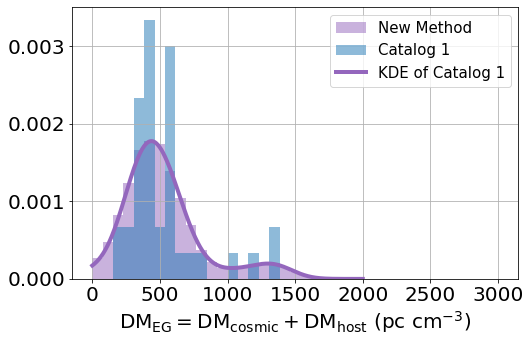

In [87]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(0,3000,40)
density=True
hist, bins, _ = plt.hist(rand_DMex, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"New Method")
hist, bins, _ = plt.hist(DMex, bins=bins, color=cycle[0], lw=4, alpha=0.5, density=density, label=f"Catalog 1")
plt.plot(dms, DMex_kde, color=cycle[4], lw=4, label='KDE of Catalog 1')
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.legend(fontsize=15)


In [88]:
# Get z and DM arrays from CHIME
# These arrays will be the same for all telescopes
sdict = prob_dmz.grab_repo_grid(telescope_dict['CHIME'])
PDM_z = sdict['pzdm']
zvals = sdict['z']
dmvals = sdict['DM']

Loading P(DM,z) grid from /arc/home/bandersen/.local/lib/python3.7/site-packages/frb/data/DM/CHIME_pzdm.npz


In [89]:
# Get the telescope specific PZDM grid
telescope = 'DSA'
if telescope and telescope != 'CHIME' and telescope != 'perfect':
    if telescope not in telescope_dict:
        raise ValueError(f"Unknown telescope: {telescope}")
    sdict = prob_dmz.grab_repo_grid(telescope_dict[telescope])
    PDM_z = sdict

Loading P(DM,z) grid from /arc/home/bandersen/.local/lib/python3.7/site-packages/frb/data/DM/DSA_pzdm.npy


In [90]:
# Interpolate
cum_all = np.cumsum(PDM_z, axis=0)
norm = np.outer(np.ones(zvals.size), cum_all[-1,:])
cum_all /= norm
cum_all[0,:] = 0.

# Interpolators
print("Building interpolators")
fs = [interp1d(cum_all[:,ii], zvals) for ii in range(dmvals.size)]

Building interpolators


In [91]:
# Iterate over sampled DMs and get redshift
zs = []
rand = np.random.uniform(size=NFRB)
for kk,DMc in enumerate(rand_DMex):
    imin = np.argmin(np.abs(dmvals-DMc))
    z = fs[imin](rand[kk])
    zs.append(float(z))
zs = np.array(zs)

In [92]:
fname = './Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df = pandas.read_csv(fname)

# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df['r-band'])
zs_mrs = np.array(df['redshift'])

# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value

# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Remove those with z > 0.2
Mrs_cut = Mrs[zs_mrs <= 0.2]

# Load the previous distribution
Mr, density = hosts_mod.load_Mr_pdf()

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

kernel = stats.gaussian_kde(Mrs_cut)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde_cut = kernel(mags)

In [93]:
# Now apparent magnitude
cum_Mr = np.cumsum(Mr_kde)
cum_Mr[0] = 0.
fMr = interp1d(cum_Mr/cum_Mr[-1], mags)
rand = np.random.uniform(size=NFRB)
rand_Mr = fMr(rand)

dist_mod = frb_cosmo.distmod(zs).value
host_m_r = dist_mod + rand_Mr

In [94]:
output_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'hco_sim_uniformoffset_expprior', 'generated_hosts_DECaL_DECaLhost_hecatecut.parquet')
hosts = pandas.read_parquet(output_fn)

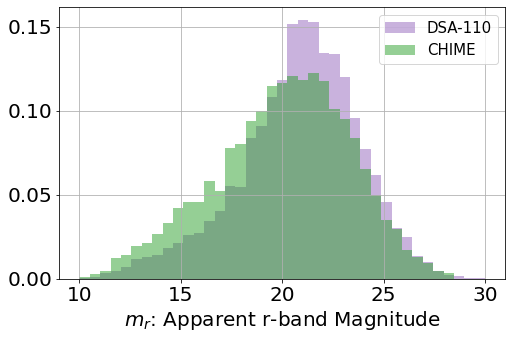

In [95]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(10, 30, 40)
density = True
hist, bins, _ = plt.hist(host_m_r, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"DSA-110")
hist, bins, _ = plt.hist(hosts['mag'], bins=bins, color=cycle[2], lw=4, alpha=0.5, density=density, label=f"CHIME")
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15)


In [96]:
generated_frbs_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'generated_frbs_fix.parquet')
frbs = pandas.read_parquet(generated_frbs_fn)

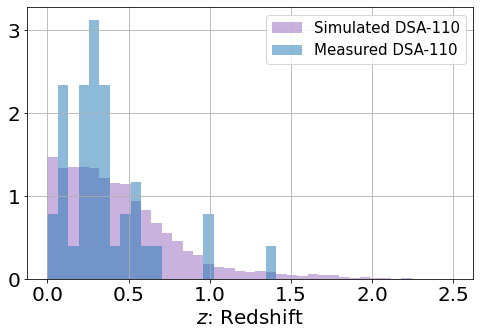

In [97]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(0,2.5,40)
density = True
hist, bins, _ = plt.hist(zs, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"Simulated DSA-110")
hist, bins, _ = plt.hist(zs_dsa, bins=bins, color=cycle[0], lw=4, alpha=0.5, density=density, label=f"Measured DSA-110")
# hist, bins, _ = plt.hist(frbs['z'], bins=bins, color=cycle[2], lw=4, alpha=0.5, density=density, label=f"CHIME")
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel('$z$: Redshift')
plt.legend(fontsize=15)


In [99]:
# Interpolate
DM, Z = np.meshgrid(dmvals, zvals)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), PDM_z.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 2000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

Text(0.5, 0, 'Redshift z')

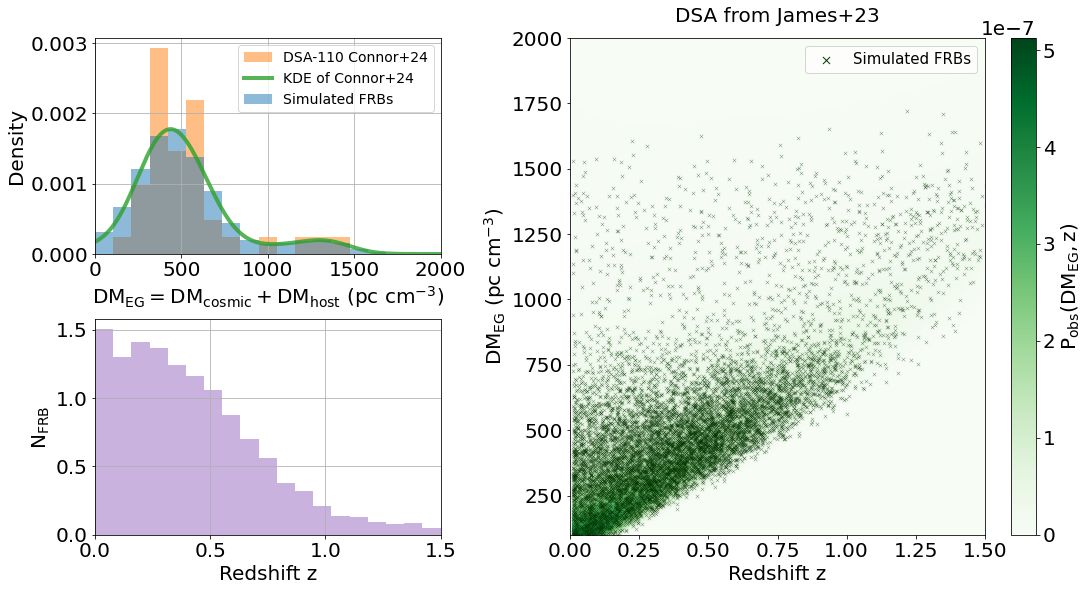

In [100]:
fig = plt.figure(figsize=(12, 6))

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    # norm=matplotlib.colors.LogNorm(vmin=1e-8), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, rand_DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 1.5])
plt.ylim([100, 2000])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'DSA from James+23', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2000,20)
density = True
hist = plt.hist(DMex, bins=bins, color=cycle[1], density=density, alpha=0.5, label='DSA-110 Connor+24')
plt.plot(dms, DMex_kde, color=cycle[2], alpha=0.8, lw=4, label='KDE of Connor+24')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
hist = plt.hist(rand_DMex, bins=bins, color=cycle[0], density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2000])
plt.ylabel('Density')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,1.5,20)
hist = plt.hist(zs, bins=bins, density=True, color=cycle[4], alpha=0.5)
plt.ylabel(r'$\rm N_{FRB}$')
plt.xlim([0,1.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'frb_props_redo.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [101]:
# Build FRB table
df_frbs = pandas.DataFrame()
df_frbs['DMex'] = rand_DMex
df_frbs['z'] = zs
df_frbs['M_r'] = rand_Mr
df_frbs['m_r'] = host_m_r
df_frbs.to_parquet('./generated_frbs_dsa.parquet')

# Generate FRBs for ASKAP

In [102]:
# Load the telescope specific grid
telescope_dict = {
    'CHIME': 'CHIME_pzdm.npz',
    'DSA': 'DSA_pzdm.npy',
    'Parkes': 'parkes_mb_class_I_and_II_pzdm.npy',
    'CRAFT': 'CRAFT_class_I_and_II_pzdm.npy',
    'CRAFT_ICS_1300': 'CRAFT_ICS_1300_pzdm.npy',
    'CRAFT_ICS_892': 'CRAFT_ICS_892_pzdm.npy',
    'CRAFT_ICS_1632': 'CRAFT_ICS_1632_pzdm.npy',
    'FAST': 'FAST_pzdm.npy',
    'perfect': 'PDM_z.npz'
}

In [107]:
# Grab DMs from ASKAP FRBs
# Shannon+24
shannon24_str = '''20180924B 2018-09-24 16:23:12.561 1297.5 24 362.4(2) 41 0.3214 21.1 2.6 18.4(9)
20181112A 2018-11-12 17:31:16.099 1297.5 12 589.0(3) 40 0.4755 19.3 3.5 28(2)
20190102C 2019-01-02 05:38:44.002 1271.5 23 364.5(3) 57 0.2912 14.0 2.6 16.0(9)
20190608B 2019-06-08 22:48:13.367 1271.5 25 339.5(5) 37 0.1178 16.1 8.6 28(2)
20190611B 2019-06-11 05:45:43.417 1271.5 25 322.2(2) 57 0.3778 9.3 3.5 10(1)
20190711A 2019-07-11 01:53:41.689 1271.5 29 594.6(5) 57 0.522 23.8 10.4 36(2)
20190714A 2019-07-14 05:37:13.606 1271.5 28 504.7(3) 39 0.2365 10.7 3.5 13(1)
20191001A 2019-10-01 16:55:37.237 920.5 30 506.92(4) 44 0.234 62.0 10.4 120(2)
20191228A 2019-12-28 09:16:18.091 1271.5 28 297.5(5) 33 0.2432 22.9 17.3 67(3)
20200430A 2020-04-30 15:49:50.041 863.5 26 380.1(2) 27 0.1608 16.0 13.8 35(2)
20200627A 2020-06-27 19:23:42.754 920.5 31 294(1) 40 -1 10.8 31.1 28(3)
20200906A 2020-09-06 21:40:53.600 863.5 7 577.8(2) 36 0.3688 16.1 5.2 53(3)
20210117A 2021-01-17 07:51:22.297 1271.5 25 730(1) 34 0.2145 27.1 5.9 36(1)
20210214G 2021-02-14 05:12:39.696 1271.5 26 398.3(7) 32 -1 11.6 4.7 13(3)
20210320C 2021-03-20 18:38:08.508 863.5 24 384.8(3) 42 0.2797 15.3 6.9 59(4)
20210407E 2021-04-07 11:20:56.806 1271.5 24 1785.3(3) 154 -1 19.1 9.5 36(2)
20210807D 2021-08-07 15:48:10.256 920.5 23 251.9(2) 121 0.1293 47.1 17.7 100(3)
20210809C 2021-08-09 10:03:02.954 920.5 23 651.5(3) 190 -1 16.8 23.6 45(3)
20210912A 2021-09-12 13:30:05.680 1271.5 23 1234.5(2) 31 -1 31.7 7.1 70(2)
20211127I 2021-11-27 00:03:51.573 1271.5 24 234.83(8) 43 0.0469 37.9 3.5 35(1)
20211203C 2021-12-03 02:21:35.468 920.5 24 636.2(4) 63 0.3439 14.2 16.5 30(2)
20211212A 2021-12-12 19:32:07.768 1631.5 24 206(5) 27 0.0707 12.8 5.9 131(7)
20220105A 2022-01-05 00:19:18.668 1631.5 22 583(2) 22 0.2785 9.8 5.9 19(2)
20220501C 2022-05-01 02:11:10.943 864.5 23 449.5(2) 31 0.381 16.1 9.5 32(2)
20220531A 2022-05-31 16:34:14.274 1271.5 23 727(2) 70 -1 9.7 10.6 30
20220610A 2022-06-10 22:26:44.313 1271.5 22 1458.1(2) 31 1.015 29.8 8.3 47(2)
20220725A 2022-07-25 21:54:53.609 920.5 25 290.4(3) 31 0.1926 12.7 8.3 72(6)
20220918A 2022-09-18 17:33:33.933 1271.5 25 656.8(4) 41 0.491 26.4 9.5 55(2)
20221106A 2022-11-06 21:27:34.504 1631.5 21 343.8(8) 35 0.2044 35.1 8.3 80(2)
20230521A 2023-05-21 02:38:08.482 831.5 23 640.2(5) 42 -1 15.2 16.5 34(1)
20230526A 2023-05-26 23:29:47.094 1271.5 22 361.4(2) 50 0.1570 22.1 4.7 34(1)
20230708A 2023-07-08 15:32:46.979 920.5 23 411.51(5) 50 0.105 31.5 23.6 111(4)
20230718A 2023-07-18 07:02:08.041 1271.5 22 477.0(5) 396 0.035 10.9 3.5 14(1)
20230731A 2023-07-31 05:28:41.587 1271.5 25 701.1(3) 547 -1 16.6 3.5 25(1)
20230902A 2023-09-02 00:48:51.836 832.5 22 440.1(1) 34 0.3619 11.8 5.9 23(2)
20231006A 2023-10-06 08:14:45.849 863.5 24 509.7(2) 68 -1 15.2 8.3 25(1)
20231226A 2023-12-26 18:46:19.997 863.5 22 329.9(1) 145 0.1569 36.7 11.8 78(3)
20240201A 2024-02-08 20:00:54.246 920.5 24 374.5(2) 38 0.042729 13.9 9.5 47(3)
20240208A 2024-02-08 20:00:54.246 863.5 14 260.2(3) 98 -1 12.1 7.1 37(3)
20240210A 2024-02-10 08:20:02.510 863.5 23 283.73(5) 31 0.023686 11.6 9.5 26(2)
20240304A 2024-03-04 17:44:55.155 863.5 24 652.6(5) 30 -1 12.3 11.8 34(2)
20240310A 2024-03-10 07:38:50 920.5 25 601.8(2) 36 0.1270 19.1 7.1 35(2)
20240318A 2024-03-18 15:14:19.454 920.5 23 256.4(3) 37 -1 13.2 4.7 15(1)'''
DMex = []
zs_askap = []
for line in shannon24_str.split('\n'):
    DMex.append(float(line.split()[5].split('(')[0]))
    zs_askap.append(float(line.split()[-4]))
DMex = np.array(DMex)
zs_askap = np.array(zs_askap)

In [111]:
# Interpolate
NFRB = 10000

kernel = stats.gaussian_kde(DMex)
dms = np.linspace(0., 2000, 500)
DMex_kde = kernel(dms)

In [112]:
# Sample DMs
cum_DMex = np.cumsum(DMex_kde)
cum_DMex[0] = 0.
fh = interp1d(cum_DMex/cum_DMex[-1], dms)

# Random numbers
rand = np.random.uniform(size=NFRB)
rand_DMex = fh(rand) # np.random.choice(df_dr1['DMex'], size=NFRB) # 

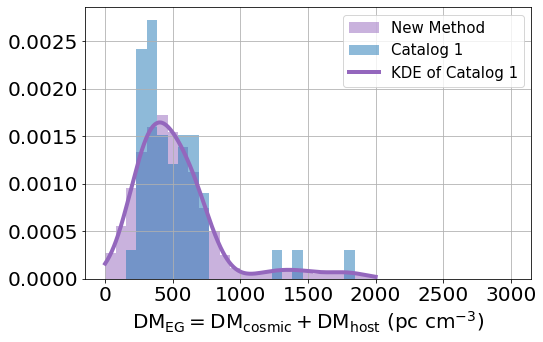

In [113]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(0,3000,40)
density=True
hist, bins, _ = plt.hist(rand_DMex, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"New Method")
hist, bins, _ = plt.hist(DMex, bins=bins, color=cycle[0], lw=4, alpha=0.5, density=density, label=f"Catalog 1")
plt.plot(dms, DMex_kde, color=cycle[4], lw=4, label='KDE of Catalog 1')
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.legend(fontsize=15)


In [121]:
# Get z and DM arrays from CHIME
# These arrays will be the same for all telescopes
sdict = prob_dmz.grab_repo_grid(telescope_dict['CHIME'])
PDM_z = sdict['pzdm']
zvals = sdict['z']
dmvals = sdict['DM']

Loading P(DM,z) grid from /arc/home/bandersen/.local/lib/python3.7/site-packages/frb/data/DM/CHIME_pzdm.npz


In [122]:
# Get the telescope specific PZDM grid
telescope = 'CRAFT'
if telescope and telescope != 'CHIME' and telescope != 'perfect':
    if telescope not in telescope_dict:
        raise ValueError(f"Unknown telescope: {telescope}")
    sdict = prob_dmz.grab_repo_grid(telescope_dict[telescope])
    PDM_z = sdict

Loading P(DM,z) grid from /arc/home/bandersen/.local/lib/python3.7/site-packages/frb/data/DM/CRAFT_class_I_and_II_pzdm.npy


In [123]:
# Interpolate
cum_all = np.cumsum(PDM_z, axis=0)
norm = np.outer(np.ones(zvals.size), cum_all[-1,:])
cum_all /= norm
cum_all[0,:] = 0.

# Interpolators
print("Building interpolators")
fs = [interp1d(cum_all[:,ii], zvals) for ii in range(dmvals.size)]

Building interpolators


In [124]:
# Iterate over sampled DMs and get redshift
zs = []
rand = np.random.uniform(size=NFRB)
for kk,DMc in enumerate(rand_DMex):
    imin = np.argmin(np.abs(dmvals-DMc))
    z = fs[imin](rand[kk])
    zs.append(float(z))
zs = np.array(zs)

In [125]:
fname = './Lz_host_data.csv' # From Alexa Gordon, complete up to Shannon+24
df = pandas.read_csv(fname)

# Scale mrs with z's to find distribution of Mrs
mrs = np.array(df['r-band'])
zs_mrs = np.array(df['redshift'])

# Get luminosity distance
ds = cosmo.luminosity_distance(zs_mrs).to(u.parsec).value

# Calculate absolute magnitudes
Mrs = mrs - 5. * np.log10(ds) + 5

# Remove those with z > 0.2
Mrs_cut = Mrs[zs_mrs <= 0.2]

# Load the previous distribution
Mr, density = hosts_mod.load_Mr_pdf()

# Calculate KDE of absolute magnitudes
kernel = stats.gaussian_kde(Mrs)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde = kernel(mags)

kernel = stats.gaussian_kde(Mrs_cut)#, bw_method=0.6)
mags = np.linspace(-25., -15., 500)
Mr_kde_cut = kernel(mags)

In [126]:
# Now apparent magnitude
cum_Mr = np.cumsum(Mr_kde)
cum_Mr[0] = 0.
fMr = interp1d(cum_Mr/cum_Mr[-1], mags)
rand = np.random.uniform(size=NFRB)
rand_Mr = fMr(rand)

dist_mod = frb_cosmo.distmod(zs).value
host_m_r = dist_mod + rand_Mr

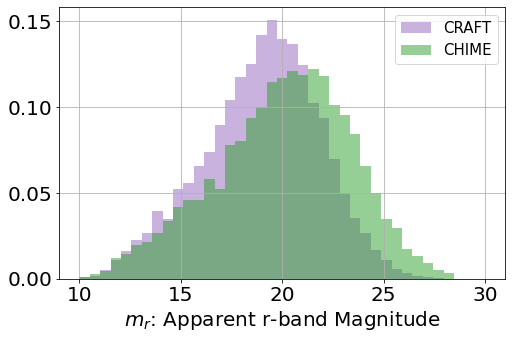

In [128]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(10, 30, 40)
density = True
hist, bins, _ = plt.hist(host_m_r, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"CRAFT")
hist, bins, _ = plt.hist(hosts['mag'], bins=bins, color=cycle[2], lw=4, alpha=0.5, density=density, label=f"CHIME")
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel('$m_r$: Apparent r-band Magnitude')
plt.legend(fontsize=15)


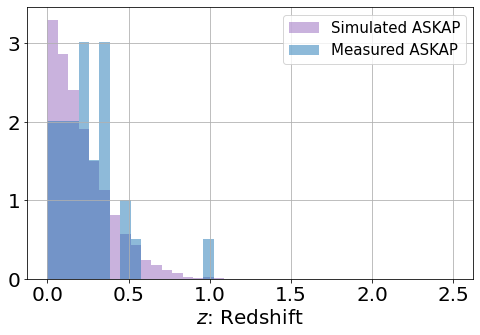

In [132]:
fig = plt.figure(figsize=(8,5))

bins = np.linspace(0,2.5,40)
density = True
hist, bins, _ = plt.hist(zs, bins=bins, color=cycle[4], lw=4, alpha=0.5, density=density, label=f"Simulated ASKAP")
hist, bins, _ = plt.hist(zs_askap, bins=bins, color=cycle[0], lw=4, alpha=0.5, density=density, label=f"Measured ASKAP")
# hist, bins, _ = plt.hist(frbs['z'], bins=bins, color=cycle[2], lw=4, alpha=0.5, density=density, label=f"CHIME")
plt.grid(zorder=1)
# plt.ylabel(r'$\rm N_{FRB}$')
plt.xlabel('$z$: Redshift')
plt.legend(fontsize=15)


In [134]:
# Interpolate
DM, Z = np.meshgrid(dmvals, zvals)  # 2D grid for interpolation
interp = CloughTocher2DInterpolator(list(zip(Z.ravel(), DM.ravel())), PDM_z.ravel(), fill_value=np.nan)
# Make new regular grid of z, dm coordinates
z_new_list = np.linspace(0, 2.5, 500)
dm_new_list = np.linspace(0, 2000, 500)
z_new, dm_new = np.meshgrid(z_new_list, dm_new_list)
Pz_dm_interp = interp(z_new, dm_new)
Pz_dm_interp[Pz_dm_interp < 0.] = 0.

Text(0.5, 0, 'Redshift z')

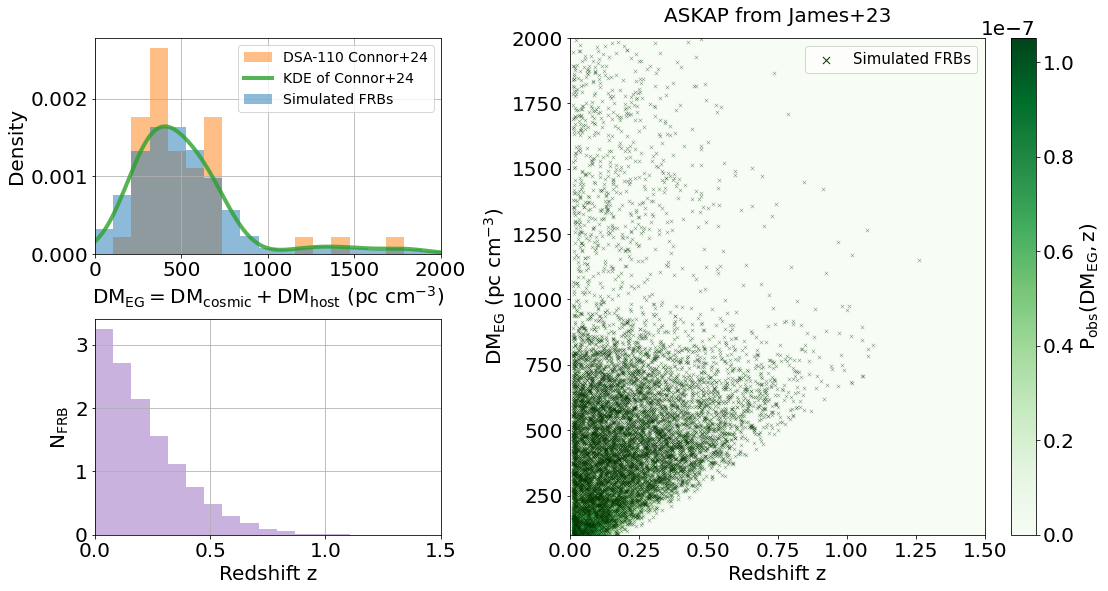

In [135]:
fig = plt.figure(figsize=(12, 6))

# (left, bottom, width, height)
height = 1/2.
sep_h = 0.15
width = 0.4
sep_w = 0.15
ax_z = (0., 0., width, height)
ax_dmeg = (0., (height+sep_h), width, height)
ax_pzdm = (width+sep_w, 0., 0.6, height*2+sep_h)

ax = plt.axes(ax_pzdm)
my_cmap = matplotlib.colormaps['Greens'] # copy the default cmap, cubehelix
# my_cmap.set_bad((0,0,0))
pc = ax.pcolormesh(
    z_new, dm_new, Pz_dm_interp, cmap=my_cmap, 
    # norm=matplotlib.colors.LogNorm(vmin=1e-8), # vmin=1e-6, vmax=2e-4
    rasterized=True,
)
plt.colorbar(pc, label=r'$\rm P_{obs}(DM_{EG},z)$')
# plt.scatter(z_samp, DM_EG_samp, color='xkcd:lightish blue', alpha=.5, s=12, linewidth=0.5, edgecolor='xkcd:dark blue', rasterized=True)
plt.scatter(zs, rand_DMex, marker='x', color='xkcd:dark green', alpha=.5, s=12, linewidth=0.5, rasterized=True, label='Simulated FRBs')
plt.xlim([0, 1.5])
plt.ylim([100, 2000])
plt.xlabel('Redshift z')
plt.ylabel(r'$\rm DM_{EG}$ (pc cm$^{-3}$)')#' = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')
plt.title(r'ASKAP from James+23', fontsize=20, y=1.02) #  $\rm P_{obs}(z|DM_{EG})$
leg = plt.legend(fontsize=15)
for lh in leg.legendHandles: 
    lh.set_alpha(1)
    lh.set_sizes([50])
    lh.set_linewidth([1])
    
ax = plt.axes(ax_dmeg)
bins = np.linspace(0,2000,20)
density = True
hist = plt.hist(DMex, bins=bins, color=cycle[1], density=density, alpha=0.5, label='DSA-110 Connor+24')
plt.plot(dms, DMex_kde, color=cycle[2], alpha=0.8, lw=4, label='KDE of Connor+24')#  / np.nanmax(DMex_kde)*np.nanmax(hist[0])
hist = plt.hist(rand_DMex, bins=bins, color=cycle[0], density=density, alpha=0.5, label='Simulated FRBs')
plt.xlim([0,2000])
plt.ylabel('Density')
plt.grid(zorder=1)
plt.legend(fontsize=14)
# _ = plt.yticks(np.arange(0, 1000+1, 500))
plt.xlabel(r'$\rm DM_{EG} = DM_{cosmic} + DM_{host}$ (pc cm$^{-3}$)')

ax = plt.axes(ax_z)
bins = np.linspace(0,1.5,20)
hist = plt.hist(zs, bins=bins, density=True, color=cycle[4], alpha=0.5)
plt.ylabel(r'$\rm N_{FRB}$')
plt.xlim([0,1.5])
plt.grid(zorder=1)
plt.xlabel(r'Redshift z')

# plot_fn = os.path.join(os.getenv('CHIME_SANDBOX'), 'paper_plot_data', 'frb_props_redo.pdf')
# plt.savefig(plot_fn, dpi=200, format="pdf", bbox_inches="tight")

In [136]:
# Build FRB table
df_frbs = pandas.DataFrame()
df_frbs['DMex'] = rand_DMex
df_frbs['z'] = zs
df_frbs['M_r'] = rand_Mr
df_frbs['m_r'] = host_m_r
df_frbs.to_parquet('./generated_frbs_askap.parquet')

# Scratch

In [77]:
def gen_random_FRBs(tel_grid, nFRBs=100):
    # Flatten and cumulative sum
    grid = tel_grid['pzdm']
    z = tel_grid['z']
    DM_EG = tel_grid['DM']
    pzDM = grid.flatten()
    cum_sum = np.cumsum(pzDM)
    # Normalize
    cum_sum = cum_sum/cum_sum[-1]
    
    randu = np.random.uniform(size=nFRBs)
    uidx = []
    for irand in randu:
        uidx.append(np.argmin(np.abs(irand-cum_sum)))
    idx = np.unravel_index(uidx, grid.shape)
    
    columns = ['DM', 'z']
    data = [DM_EG[idx[1]], z[idx[0]]]
    df = pd.DataFrame(data, columns=columns)
    
    return df

In [74]:
chime_grid = prob_dmz.grab_repo_grid(prob_dmz.telescope_dict['CHIME'])

Loading P(DM,z) grid from /arc/home/bandersen/.local/lib/python3.7/site-packages/frb/data/DM/CHIME_pzdm.npz


In [78]:
dsa_pzdm = prob_dmz.grab_repo_grid(prob_dmz.telescope_dict['DSA'])
dsa_grid = dict(z=chime_grid['z'], DM=chime_grid['DM'], pzdm=dsa_pzdm)
df_dsa = gen_random_FRBs(dsa_grid, nFRBs=100)

Loading P(DM,z) grid from /arc/home/bandersen/.local/lib/python3.7/site-packages/frb/data/DM/DSA_pzdm.npz


AttributeError: 'NpzFile' object has no attribute 'flatten'

In [79]:
dsa_pzdm

In [81]:
prob_dmz.telescope_dict['DSA']

'DSA_pzdm.npz'

In [80]:
telescope_dict

{'CHIME': 'CHIME_pzdm.npz',
 'DSA': 'DSA_pzdm.npy',
 'Parkes': 'parkes_mb_class_I_and_II_pzdm.npy',
 'CRAFT': 'CRAFT_class_I_and_II_pzdm.npy',
 'CRAFT_ICS_1300': 'CRAFT_ICS_1300_pzdm.npy',
 'CRAFT_ICS_892': 'CRAFT_ICS_892_pzdm.npy',
 'CRAFT_ICS_1632': 'CRAFT_ICS_1632_pzdm.npy',
 'FAST': 'FAST_pzdm.npy',
 'perfect': 'PDM_z.npz'}